# Deep Learning in NLP: Sequence Models & Text Classification

How do modern **Deep Learning sequence models** process text in practical NLP pipelines?

In earlier notebooks, we explored:
- **Notebook 1**: Subword Tokenization & **BPE** (`tiktoken`)
- **Notebook 2**: Dense **Embeddings & Vector Spaces**

Now, we connect these pieces into a complete end-to-end Deep Learning pipeline: using a **BPE tokenizer** (`tiktoken`) to convert raw text into token IDs, mapping them through an **Embedding Layer**, processing the sequence with an **LSTM**, and training a sentiment classifier on the **IMDB Dataset**.

---

### What we will cover:
1. **The NLP Sequence Perspective**: How neural networks represent text as sequential vectors
2. **Dataset**: Loading the IMDB Movie Reviews dataset
3. **The 5-Stage Deep Learning NLP Pipeline**:
   - **Subword Tokenization** using `tiktoken` (BPE)
   - **Padding & Sequence Lengths** (Why padding is required and how it works)
   - **Embedding Layer** (`nn.Embedding` with `padding_idx=0`)
   - **LSTM Sequence Layer** (Accumulating contextual hidden state over time)
   - **Classification Head** (Logits $\to$ Predictions)
4. **Training the PyTorch LSTM Classifier** with loss & accuracy curves
5. **Evaluation**: Classification report and Confusion Matrix
6. **Interactive Inference** on tricky sentences with negations
7. **Summary & Hands-on Assignment**

## 0. Setup and Imports

We include `%matplotlib inline` to ensure all charts render cleanly in Google Colab and Jupyter.

In [ ]:
# Enable inline plotting for Google Colab and Jupyter
%matplotlib inline

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tiktoken

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Plotting aesthetic settings
plt.style.use('default')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. How Deep Learning Models Represent Text

In Deep Learning, text is treated as an **ordered sequence of dense vectors**:

$$\text{Review} = [\mathbf{x}_1, \mathbf{x}_2, \mathbf{x}_3, \dots, \mathbf{x}_T]$$

As the model reads each vector $\mathbf{x}_t$, it updates a running internal **hidden state** $\mathbf{h}_t$:

$$\mathbf{h}_t = \text{LSTM}(\mathbf{x}_t, \mathbf{h}_{t-1})$$

This allows the model to:
- Remember **earlier words** (e.g. `not` or `never`) when reading **later words** (e.g. `good` or `recommend`)
- Understand **word order**, syntax, and sentence structure
- Produce a final summary vector $\mathbf{h}_T$ that captures the full semantic meaning of the document

## 2. Load the IMDB Movie Reviews Dataset

We use the classic **IMDB dataset** containing movie reviews labeled as **positive** (`1`) or **negative** (`0`).

We select a balanced subset of **10,000 reviews** (8,000 train / 2,000 test) for fast and interactive training.

In [ ]:
# Find dataset path

df =  pd.read_csv("https://raw.githubusercontent.com/Muhammed-M/iti-summer-training-aug2026/main/NLP/datasets/IMDB-Dataset.csv")
print(f'Full dataset shape: {df.shape}')

# Map labels: 'positive' -> 1, 'negative' -> 0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Take balanced sample of 10,000 reviews for rapid classroom training
SAMPLE_SIZE = 10000
df_sample = df.groupby('label', group_keys=False).apply(lambda x: x.sample(SAMPLE_SIZE // 2, random_state=42))
df_sample = df_sample.sample(frac=1.0, random_state=42).reset_index(drop=True)

# Split into Train (80%) and Test (20%)
train_texts, test_texts, y_train, y_test = train_test_split(
    df_sample['review'].tolist(),
    df_sample['label'].values,
    test_size=0.20,
    random_state=42,
    stratify=df_sample['label'].values
)

print(f'Training reviews : {len(train_texts):,}')
print(f'Testing reviews  : {len(test_texts):,}')
print('\nSample training review:')
print(train_texts[0][:180], '...')

Full dataset shape: (50000, 2)
Training reviews : 8,000
Testing reviews  : 2,000

Sample training review:
A really bad sequel. Part 1 had a lot of funny moments - part 2 is just bad (in a boring way) and obviously made to squeeze money out of the fans.<br /><br />Shame on you, Otto Waa ...


/tmp/ipykernel_2398/2503448151.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('label', group_keys=False).apply(lambda x: x.sample(SAMPLE_SIZE // 2, random_state=42))


---
## 3. The Deep Learning NLP Pipeline (Step-by-Step)

Here is the complete end-to-end data flow:

```
1. Raw Review:      "The acting was unbelievably good!"
                         │
                         ▼
2. tiktoken (BPE):   ['The', ' acting', ' was', ' unbelie', 'vably', ' good', '!']
                         │
                         ▼
3. Token IDs:        [ 464,    3945,     373,     59092,    1884,    922,   0 ]
                         │
                         ▼
4. PADDING:          [ 464,    3945,     373,     59092,    1884,    922,   0,   0,   0, ... ]  <- fixed MAX_LEN
                         │
                         ▼
5. Embedding Layer:  [ [0.2, -0.4, ...], [0.8, 0.1, ...], ... ]  (dense vector per subword)
                         │
                         ▼
6. LSTM Layer:       Processes sequence step by step -> Final Hidden State h_T (Summary Vector)
                         │
                         ▼
7. Linear Head:      Binary classification logit -> Sigmoid Probability (Positive vs Negative)
```

### Step A: Subword Tokenization with `tiktoken` (BPE)

In [ ]:
# Use the standard cl100k_base BPE tokenizer
tokenizer = tiktoken.get_encoding('cl100k_base')
VOCAB_SIZE = tokenizer.n_vocab

print(f'Tokenizer: cl100k_base')
print(f'Vocabulary size: {VOCAB_SIZE:,} subwords')

# Demo on sample text
demo_text = "The cinematography was breathtakingly beautiful!"
demo_ids = tokenizer.encode(demo_text)
demo_subwords = [tokenizer.decode([tid]) for tid in demo_ids]

print(f'\nText        : "{demo_text}"')
print(f'Subwords ({len(demo_subwords)}): {demo_subwords}')
print(f'Token IDs   : {demo_ids}')

Tokenizer: cl100k_base
Vocabulary size: 100,277 subwords

Text        : "The cinematography was breathtakingly beautiful!"
Subwords (8): ['The', ' cinemat', 'ography', ' was', ' breathtaking', 'ly', ' beautiful', '!']
Token IDs   : [791, 88122, 5814, 574, 57192, 398, 6366, 0]


### Step B: Sequence Length & PADDING

> #### Why is Padding essential?
> 1. **Variable Lengths**: Natural sentences have different lengths (e.g. 15 words vs 300 words).
> 2. **Batch Processing**: Neural networks process reviews in batches (e.g. 64 reviews at once) as fixed rectangular tensors of shape `(batch_size, sequence_length)`.
> 3. **The Solution**: We fix `MAX_LEN = 200`.
>    - Reviews **longer** than `MAX_LEN` are **truncated**.
>    - Reviews **shorter** than `MAX_LEN` are **padded** with `0` (`<PAD>`) at the end.
>
> ```
> Short Review (4 tokens) : [ 1205,  3945,  6582,   340 ]
> Padded (MAX_LEN = 7)    : [ 1205,  3945,  6582,   340,    0,    0,    0 ]  <- 0 is <PAD>
> ```

In [ ]:
MAX_LEN = 200  # maximum sequence length

def encode_and_pad(text, tokenizer, max_len=200):
    """Clean HTML, tokenize with tiktoken, and pad/truncate to max_len."""
    # Remove HTML line breaks
    text = re.sub(r'<.*?>', ' ', str(text))

    # BPE tokenization to integer IDs
    ids = tokenizer.encode(text)

    # Pad or truncate
    if len(ids) < max_len:
        ids = ids + [0] * (max_len - len(ids))  # pad with 0
    else:
        ids = ids[:max_len]                     # truncate
    return ids

# Demo on a short text
sample = "Loved the movie!"
padded = encode_and_pad(sample, tokenizer, max_len=8)
print(f'Sample text      : "{sample}"')
print(f'Padded IDs (L=8) : {padded}')

Sample text      : "Loved the movie!"
Padded IDs (L=8) : [43, 5047, 279, 5818, 0, 0, 0, 0]


In [ ]:
# Encode training and testing datasets
print('Tokenizing and padding dataset...')
X_train_encoded = np.array([encode_and_pad(t, tokenizer, MAX_LEN) for t in train_texts])
X_test_encoded  = np.array([encode_and_pad(t, tokenizer, MAX_LEN) for t in test_texts])

print(f'X_train tensor shape: {X_train_encoded.shape}  (8,000 reviews x {MAX_LEN} tokens)')
print(f'X_test tensor shape : {X_test_encoded.shape}  (2,000 reviews x {MAX_LEN} tokens)')

# Create PyTorch DataLoaders
BATCH_SIZE = 64

train_dataset = TensorDataset(
    torch.tensor(X_train_encoded, dtype=torch.long),
    torch.tensor(y_train, dtype=torch.float32)
)
test_dataset = TensorDataset(
    torch.tensor(X_test_encoded, dtype=torch.long),
    torch.tensor(y_test, dtype=torch.float32)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'DataLoaders created: {len(train_loader)} train batches, {len(test_loader)} test batches.')

Tokenizing and padding dataset...
X_train tensor shape: (8000, 200)  (8,000 reviews x 200 tokens)
X_test tensor shape : (2000, 200)  (2,000 reviews x 200 tokens)
DataLoaders created: 125 train batches, 32 test batches.


### Step C & D: The PyTorch Model Architecture

The neural network consists of three layers:
1. **`nn.Embedding(vocab_size, embed_dim, padding_idx=0)`**:
   - Maps token integers to 64-dimensional dense vectors.
   - `padding_idx=0` tells PyTorch to keep padding vectors fixed at zero.
2. **`nn.LSTM(embed_dim, hidden_dim, batch_first=True)`**:
   - Processes the sequence sequentially, updating its hidden state.
   - The final hidden state $h_T$ serves as a learned summary vector of the review.
3. **`nn.Linear(hidden_dim, 1)`**:
   - Classification head mapping the summary vector to a sentiment score.

In [ ]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=64, dropout=0.3):
        super().__init__()
        # 1. Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # 2. LSTM Sequence Layer
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        # 3. Regularization & Output Linear Layer
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embeds = self.embedding(x)                # (batch_size, seq_len, embed_dim)

        # LSTM forward pass
        lstm_out, (h_n, c_n) = self.lstm(embeds) # h_n: (1, batch_size, hidden_dim)

        # Final hidden state represents the sequence summary
        final_state = self.dropout(h_n[-1])       # (batch_size, hidden_dim)
        logits = self.fc(final_state).squeeze(1)  # (batch_size,)
        return logits

# Instantiate the model
EMBED_DIM  = 64
HIDDEN_DIM = 64

model = SentimentLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')

SentimentLSTM(
  (embedding): Embedding(100277, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total trainable parameters: 6,451,073


## 4. Training the LSTM Classifier

We train with **Binary Cross Entropy with Logits Loss** (`BCEWithLogitsLoss`) and **Adam optimizer** for 6 epochs.

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

EPOCHS = 30
train_losses = []
test_accuracies = []

print('Starting Training...')
print('-' * 55)

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_x.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Evaluate on test set
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            preds = (torch.sigmoid(model(batch_x)) >= 0.5).float()
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)

    epoch_acc = (correct / total) * 100
    test_accuracies.append(epoch_acc)

    print(f'Epoch [{epoch}/{EPOCHS}] | Train Loss: {epoch_loss:.4f} | Test Accuracy: {epoch_acc:.2f}%')

Starting Training...
-------------------------------------------------------
Epoch [1/30] | Train Loss: 0.4115 | Test Accuracy: 60.85%
Epoch [2/30] | Train Loss: 0.3558 | Test Accuracy: 62.20%
Epoch [3/30] | Train Loss: 0.3176 | Test Accuracy: 60.35%
Epoch [4/30] | Train Loss: 0.3002 | Test Accuracy: 61.25%
Epoch [5/30] | Train Loss: 0.2937 | Test Accuracy: 62.80%
Epoch [6/30] | Train Loss: 0.2749 | Test Accuracy: 61.60%
Epoch [7/30] | Train Loss: 0.2840 | Test Accuracy: 65.75%
Epoch [8/30] | Train Loss: 0.2506 | Test Accuracy: 65.10%
Epoch [9/30] | Train Loss: 0.2496 | Test Accuracy: 64.05%
Epoch [10/30] | Train Loss: 0.2814 | Test Accuracy: 54.00%
Epoch [11/30] | Train Loss: 0.2829 | Test Accuracy: 66.85%
Epoch [12/30] | Train Loss: 0.2126 | Test Accuracy: 66.70%
Epoch [13/30] | Train Loss: 0.1918 | Test Accuracy: 69.80%
Epoch [14/30] | Train Loss: 0.4343 | Test Accuracy: 53.50%
Epoch [15/30] | Train Loss: 0.3058 | Test Accuracy: 62.20%
Epoch [16/30] | Train Loss: 0.2208 | Test Accur

### Visualizing Training Progress (Loss & Accuracy)

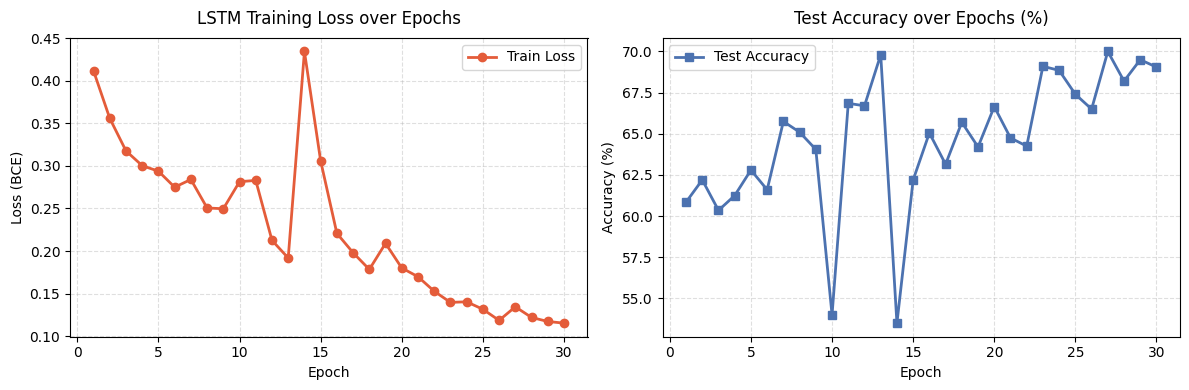

In [ ]:
# Plot Training Loss and Test Accuracy Curves
plt.figure(figsize=(12, 4))

# Subplot 1: Training Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', color='#E45C3A', linewidth=2, label='Train Loss')
plt.title('LSTM Training Loss over Epochs', fontsize=12, pad=10)
plt.xlabel('Epoch')
plt.ylabel('Loss (BCE)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

# Subplot 2: Test Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), test_accuracies, marker='s', color='#4C72B0', linewidth=2, label='Test Accuracy')
plt.title('Test Accuracy over Epochs (%)', fontsize=12, pad=10)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

## 5. Model Evaluation on Test Data

Let's compute detailed classification metrics and plot the **Confusion Matrix**.

In [ ]:
# Gather all predictions on test dataset
model.eval()
all_preds = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        probs = torch.sigmoid(model(batch_x))
        preds = (probs >= 0.5).int().cpu().numpy()
        all_preds.extend(preds)

y_pred = np.array(all_preds)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)

print(f'=== LSTM CLASSIFIER EVALUATION ===')
print(f'Overall Accuracy: {acc * 100:.2f}%')
print(f'Macro F1 Score  : {f1 * 100:.2f}%\n')
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

=== LSTM CLASSIFIER EVALUATION ===
Overall Accuracy: 69.05%
Macro F1 Score  : 71.67%

              precision    recall  f1-score   support

    Negative       0.73      0.60      0.66      1000
    Positive       0.66      0.78      0.72      1000

    accuracy                           0.69      2000
   macro avg       0.70      0.69      0.69      2000
weighted avg       0.70      0.69      0.69      2000



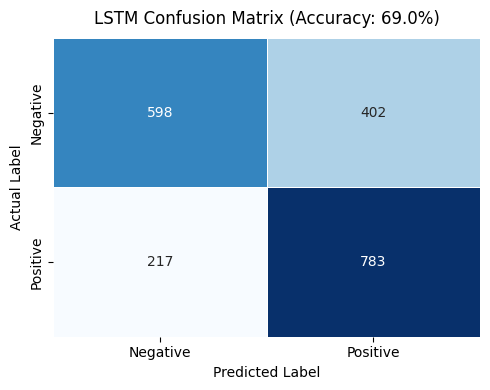

In [ ]:
# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    cbar=False,
    linewidths=0.5,
    linecolor='white'
)
plt.title(f'LSTM Confusion Matrix (Accuracy: {acc*100:.1f}%)', fontsize=12, pad=10)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

## 6. Interactive Prediction on New Reviews

Let's test the trained model on sentences containing **negations** and **qualifiers**:

In [ ]:
def predict_sentiment(review_text):
    """Run inference on raw user input using the trained LSTM model."""
    model.eval()
    encoded = encode_and_pad(review_text, tokenizer, MAX_LEN)
    tensor_in = torch.tensor([encoded], dtype=torch.long).to(device)

    with torch.no_grad():
        prob = torch.sigmoid(model(tensor_in)).item()

    label = 'Positive 👍' if prob >= 0.5 else 'Negative 👎'
    confidence = prob if prob >= 0.5 else (1 - prob)

    print(f'Review: "{review_text}"')
    print(f'  Prediction : {label} (Confidence: {confidence*100:.1f}%)\n')

# Test cases
predict_sentiment('This movie was not good at all, completely boring.')
predict_sentiment('I thought it would be bad movie, but it turned out to be an absolute masterpiece!')
predict_sentiment('Waste of time and money, terrible acting.')
predict_sentiment('Superb acting, and an incredible ending.')

Review: "This movie was not good at all, completely boring."
  Prediction : Negative 👎 (Confidence: 97.4%)

Review: "I thought it would be bad movie, but it turned out to be an absolute masterpiece!"
  Prediction : Positive 👍 (Confidence: 71.5%)

Review: "Waste of time and money, terrible acting."
  Prediction : Negative 👎 (Confidence: 99.4%)

Review: "Superb acting, and an incredible ending."
  Prediction : Positive 👍 (Confidence: 71.5%)



## 7. Summary & Looking Ahead to Transformers

| Component | What it does in the Pipeline |
| --- | --- |
| **`tiktoken` (BPE)** | Splits any text into subwords without `<UNK>` errors |
| **Padding (`MAX_LEN`)** | Standardizes sequences into uniform tensor dimensions for batching |
| **`nn.Embedding`** | Maps token IDs to continuous 64-dimensional dense vectors |
| **`nn.LSTM`** | Reads vectors sequentially, accumulating contextual memory over time |
| **`nn.Linear`** | Maps the final hidden vector to a sentiment prediction |

> **The Limitation of Recurrence**:
> LSTMs process text strictly **one token at a time** (sequential dependency), making them slow to train on long documents.
> In **Notebook 4 (`02-04-transformers.ipynb`)**, we will see how **Transformers and Attention Mechanisms** process all tokens in parallel!

In [ ]:
# TODO: Mini Assignment
#
# 1. Test the predict_sentiment() function on 3 new reviews written by you.
# 2. Experiment with sequence length: what happens if you change MAX_LEN to 50 vs 300?
# 3. (Bonus Challenge): Modify SentimentLSTM to be Bidirectional:
#    - Set nn.LSTM(..., bidirectional=True)
#    - Adjust the linear layer input from hidden_dim to hidden_dim * 2
#    - Train for 3 epochs and compare the test accuracy!

# Write your experiment code here:
